In [1]:
import os
import qsprpred
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
def load_datasets(path):
    dataset = QSPRDataset.fromTableFile(
    filename=path,
    store_dir="dataset_outputs/A2AR/data",
    name="A2ARDataset",
    target_props=[{"name": "Y", "task": "SINGLECLASS", "th": [0.5]}],
    random_state=42,
    smiles_col = 'Drug',
    sep=','
    )
    dataset.prepareDataset(
    feature_calculators=[MorganFP(radius=2, nBits=1024)],
    recalculate_features=True,
    shuffle=False
    )
    from qsprpred.data.descriptors.sets import RDKitDescs
    
    rdkit_descs = RDKitDescs()
    
    dataset.addDescriptors([rdkit_descs])
    
    dataset.descriptorSets
    return dataset
    

In [3]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForMaskedLM, DataCollatorWithPadding
from sklearn.base import BaseEstimator, TransformerMixin

class SMILESDataset(Dataset):
    def __init__(self, smiles, tokenizer, max_len=128):
        self.smiles = smiles
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smile = self.smiles[idx]
        encoding = self.tokenizer(smile, truncation=True, padding='max_length', max_length=self.max_len, return_tensors='pt')
        return encoding


class ChemBERTaTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, model_name="entropy/roberta_zinc_480m", max_len=128, batch_size=32, device=None):
        self.model_name = model_name
        self.max_len = max_len
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = RobertaForMaskedLM.from_pretrained(self.model_name).to(self.device)
        self.tokenizer = RobertaTokenizerFast.from_pretrained(self.model_name, max_len=self.max_len)
        self.collator = DataCollatorWithPadding(self.tokenizer, padding=True, return_tensors='pt')
        self.embedding_dim = None  # bude nastaven po fit()

    def fit(self, X, y=None):
        # Zjistíme embedding dimenzi na prvním SMILES
        smiles_dataset = SMILESDataset(X, self.tokenizer, max_len=self.max_len)
        dataloader = DataLoader(smiles_dataset, batch_size=1, collate_fn=self.collator)
        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].squeeze(1).to(self.device)
                attention_mask = batch['attention_mask'].squeeze(1).to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
                embedding = outputs[1][-1]  # poslední hidden state
                self.embedding_dim = embedding.shape[-1]
                break
        return self

    def transform(self, X):
        self.model.eval()
        smiles_dataset = SMILESDataset(X, self.tokenizer, max_len=self.max_len)
        dataloader = DataLoader(smiles_dataset, batch_size=self.batch_size, collate_fn=self.collator)
        embeddings_list = []

        with torch.no_grad():
            for batch in dataloader:
                input_ids = batch['input_ids'].squeeze(1).to(self.device)
                attention_mask = batch['attention_mask'].squeeze(1).to(self.device)
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
                full_embeddings = outputs[1][-1]
                embeddings = ((full_embeddings * attention_mask.unsqueeze(-1)).sum(1) / attention_mask.sum(-1).unsqueeze(-1))
                embeddings_list.append(embeddings)

        all_embeddings = torch.cat(embeddings_list, dim=0).cpu().numpy()
        column_names = [f"chemberta_{i}" for i in range(self.embedding_dim)]
        return pd.DataFrame(all_embeddings, columns=column_names)


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X1_all = load_datasets("A2AR/data/a2ar_train_1")

X2_all = load_datasets("A2AR/data/a2ar_val_1")

X3_all = load_datasets("A2AR/data/a2ar_test_1")

CNC(=O)C12CC1C(n1cnc3c(NCc4ccccc4C)nc(Cl)nc31)C(O)C2O


/tmp/ipykernel_4438/3597161672.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(X1_all.df['Drug'][10])
/tmp/ipykernel_4438/3597161672.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MolGraph(X1_all.df['Drug'][10])


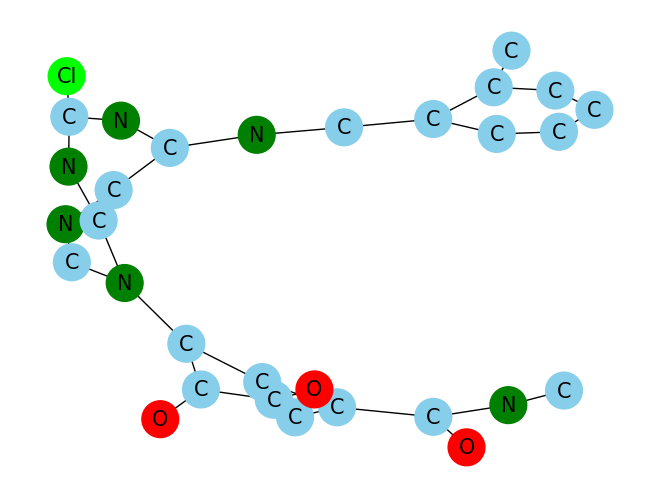

In [5]:
from MolEval.MolGraph import MolGraph
print(X1_all.df['Drug'][10])
MolGraph(X1_all.df['Drug'][10])

In [6]:
from MolEval import MolEmb 
model_name = 'RoBERTa_ZINC'  # Replace with the model you want to use
X1_all.df["SMILES"] = X1_all.df["Drug"]
extractor = MolEmb.EmbeddingExtractor(model_name=model_name, df=X1_all.df)
emb, df = extractor.get_embeddings()
print(emb)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'
Some weights of RobertaModel were not initialized from the model checkpoint at entropy/roberta_zinc_480m and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.p

           0         1         2         3         4         5         6    \
0     0.407260  0.495347  0.274203 -0.739150 -0.834823 -0.122703  0.166830   
1     0.476131  0.388502  0.711610 -0.695635  0.003911  0.413197  0.211556   
2     0.306410  0.063509  0.647057 -0.511375 -0.220997 -0.198375 -0.468208   
3     0.230208 -0.019390  0.895873 -0.356856  0.095086  0.612508  0.067613   
4     0.266686  0.322516  0.284747 -0.822343 -0.819355  0.070184  0.073638   
...        ...       ...       ...       ...       ...       ...       ...   
2402 -0.015544 -0.054512  0.369423 -0.778165 -0.397768  0.000692  0.279468   
2403  0.304399  0.264488  1.050048 -0.891057 -0.884759 -0.088258  0.369241   
2404 -0.135071  0.134013  0.372034 -0.785454 -0.298855 -0.138716 -0.337679   
2405 -0.122916  0.191554  0.471945 -0.943610 -0.548200 -0.237599 -0.267154   
2406  0.189195  0.160338  0.643033 -0.424435 -0.327641  0.050572  0.089013   

           7         8         9    ...       758       759    

In [7]:
X2_all.df["SMILES"] = X2_all.df["Drug"]
extractor2 = MolEmb.EmbeddingExtractor(model_name=model_name, df=X2_all.df)
emb2, df2 = extractor2.get_embeddings()

Some weights of RobertaModel were not initialized from the model checkpoint at entropy/roberta_zinc_480m and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
display(emb)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.407260,0.495347,0.274203,-0.739150,-0.834823,-0.122703,0.166830,-0.131784,0.355817,0.634529,...,0.016533,0.195609,-0.674374,-0.065700,0.370229,-0.326461,0.348396,-0.086251,0.064743,-0.962521
1,0.476131,0.388502,0.711610,-0.695635,0.003911,0.413197,0.211556,-0.614364,0.111648,-0.290829,...,-0.117531,0.066307,0.073473,0.053947,-0.011456,0.248302,0.882871,-0.134034,0.101105,-0.926051
2,0.306410,0.063509,0.647057,-0.511375,-0.220997,-0.198375,-0.468208,-0.250490,0.501485,0.212982,...,-0.051249,0.019601,-0.234947,-0.663630,-0.225576,0.667409,0.739919,-0.373016,-0.551484,-0.496429
3,0.230208,-0.019390,0.895873,-0.356856,0.095086,0.612508,0.067613,-0.554890,0.241365,-0.432577,...,-0.224458,0.155745,-0.224500,0.159243,-0.185103,-0.191579,0.361649,0.198005,-0.138387,-0.536161
4,0.266686,0.322516,0.284747,-0.822343,-0.819355,0.070184,0.073638,-0.205792,0.281555,0.629372,...,0.066663,0.252491,-0.544621,-0.063162,0.201588,-0.360610,0.267816,-0.085702,-0.012495,-0.989619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2402,-0.015544,-0.054512,0.369423,-0.778165,-0.397768,0.000692,0.279468,-0.433743,0.248409,0.032826,...,0.448256,0.491986,-0.357603,-0.081183,-0.278233,-0.135188,0.569269,-0.283329,-0.071396,-0.738980
2403,0.304399,0.264488,1.050048,-0.891057,-0.884759,-0.088258,0.369241,-0.238191,0.407311,0.001604,...,0.128226,0.159901,-0.013588,-0.477770,0.085022,0.110087,0.779071,-0.281327,0.103782,-0.730889
2404,-0.135071,0.134013,0.372034,-0.785454,-0.298855,-0.138716,-0.337679,-0.325664,0.204237,0.024997,...,0.448488,-0.177408,-0.629834,-0.152293,-0.186566,0.062021,0.700484,-0.078713,0.170892,-0.848403
2405,-0.122916,0.191554,0.471945,-0.943610,-0.548200,-0.237599,-0.267154,-0.257961,0.409531,0.300807,...,0.141541,0.003172,-0.304752,-0.335208,0.216789,-0.193689,0.674777,-0.341150,0.009661,-0.460586


In [9]:
display(emb2)

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.873531,0.355381,0.538476,-0.495770,-0.405989,0.163620,-0.082884,-0.706999,0.100894,-0.406464,...,0.160275,0.074426,-0.518734,0.101278,-0.156424,0.031466,0.673024,-0.142087,0.005847,-0.514030
1,0.091718,0.471411,1.129325,-0.751875,-0.378658,0.227308,0.080482,-0.380502,0.098596,0.190684,...,-0.071860,0.097292,-0.087929,-0.173101,-0.028672,0.364821,0.444170,-0.072584,-0.070252,-0.751666
2,-0.222654,0.257709,0.529388,-0.291717,-0.306762,-0.357013,0.262504,-0.647370,0.593615,0.062135,...,0.240745,-0.182091,-0.124104,0.135646,-0.196018,0.062310,0.405304,-0.025201,-0.037708,-0.288250
3,-0.176052,0.037503,0.197305,-0.663523,-0.508263,-0.133018,-0.289507,-0.217929,0.498442,0.082283,...,-0.206691,-0.008207,-0.330072,0.202808,-0.006964,-0.197738,0.276310,-0.276212,0.083365,0.176815
4,-0.337213,0.330122,0.872076,-0.536321,-0.666272,0.038893,0.338998,-0.480992,0.342904,-0.133478,...,-0.134913,0.063050,0.034673,-0.253225,-0.190716,0.256710,0.698061,0.042128,0.049520,-0.676471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,0.494384,0.173970,0.528642,-0.574440,0.032508,0.453415,0.362845,-0.531501,-0.154964,-0.120939,...,0.045980,0.137823,0.132906,0.014447,0.027588,0.099928,0.680277,-0.119590,0.073923,-0.639346
807,0.690581,0.951623,0.463462,-0.745599,0.155555,-0.868633,-0.295477,-0.047182,0.010665,0.097834,...,0.525436,-0.305444,-0.077900,-0.097706,0.587755,0.097803,0.859146,-0.597544,0.245550,-0.272907
808,-0.242162,0.141084,1.164703,-0.325766,-0.580914,0.137717,0.229198,-0.474013,0.095407,0.029580,...,0.270919,-0.161545,-0.195868,-0.026008,0.102916,0.140246,0.669294,-0.233838,0.130424,-0.477552
809,0.324993,0.202570,0.307981,-0.819219,-0.500415,-0.034391,0.069246,-0.192231,0.058351,0.020215,...,0.045195,0.249221,-0.354409,0.071646,0.125062,0.288560,0.914358,-0.259063,0.250934,-0.480186


In [10]:
X3_all.df["SMILES"] = X3_all.df["Drug"]
extractor3 = MolEmb.EmbeddingExtractor(model_name=model_name, df=X3_all.df)
emb3, df3 = extractor3.get_embeddings()
display(emb3)

Some weights of RobertaModel were not initialized from the model checkpoint at entropy/roberta_zinc_480m and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,0.386719,0.381083,0.880282,-0.129743,-0.470441,-0.114146,-0.159469,-0.030283,-0.000007,0.026210,...,0.066493,0.313761,-0.687266,-0.086003,0.015799,0.499730,0.417170,-0.433060,0.025140,-0.010341
1,-0.012329,0.042199,0.504797,-0.618440,-0.385152,-0.075733,-0.175865,-0.276319,0.085730,-0.073594,...,0.427338,-0.119034,-0.220593,-0.327747,0.018900,-0.180831,0.066138,-0.359251,0.187227,-0.331075
2,-0.001275,0.351681,-0.184632,-0.400371,-0.105561,-0.542973,-0.264007,-0.335495,0.483654,-0.111056,...,0.361555,-0.109810,-0.367811,0.251796,-0.052785,0.133834,0.889266,-0.269218,0.163290,-0.007741
3,0.167022,-0.086106,1.136180,-0.638436,-0.928782,-0.105735,0.175153,-0.466891,0.322132,0.216780,...,0.212281,0.368771,0.153928,-0.228844,0.012988,-0.085077,0.429632,-0.064018,0.113950,-0.692819
4,0.490396,0.334122,0.657319,-0.449941,0.053929,-0.108533,-0.598582,-0.062289,0.383462,-0.057425,...,0.089385,-0.039821,-0.385214,-0.412184,0.306683,0.209005,0.888776,-0.416939,-0.295426,-0.088778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,0.052062,0.478242,0.806653,-0.170751,-0.212051,-0.295561,0.021265,-0.250210,0.466819,-0.440708,...,0.345739,0.057034,-0.583898,0.379561,0.059571,0.227318,0.444394,-0.437739,-0.166733,-0.312971
860,0.412520,0.358542,0.688755,-0.480238,0.016253,-0.103067,-0.516215,0.053010,0.326925,-0.202634,...,0.145041,-0.117903,-0.560734,-0.329986,0.331400,0.219667,0.757997,-0.191230,-0.352478,-0.287249
861,-0.149935,0.551970,1.227802,-0.532420,-0.696333,0.053194,-0.011067,-0.454298,0.083504,-0.205197,...,0.213534,-0.054093,-0.417278,-0.043411,0.111895,0.549025,0.621648,-0.193246,0.065221,-0.679957
862,0.222756,-0.158766,1.262556,-0.791267,-0.951162,-0.055650,0.117749,-0.518983,0.356668,0.236803,...,0.153356,0.322790,0.172389,-0.212086,0.009056,-0.047872,0.381528,-0.032149,0.240377,-0.631686


In [11]:
transformer = ChemBERTaTransformer()
X_train_emb = transformer.fit_transform(X1_all.df["Drug"])
X_val_emb = transformer.transform(X2_all.df["Drug"])
X_test_emb = transformer.transform(X3_all.df["Drug"])

/tmp/ipykernel_9224/195630644.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  smile = self.smiles[idx]


In [12]:
import pandas as pd
X1_all.X = X1_all.X.reset_index(drop=True)
X_train_emb = X_train_emb.reset_index(drop=True)
X1_all.X = pd.concat([X1_all.X, X_train_emb], axis = 1)

In [13]:
X2_all.X = X2_all.X.reset_index(drop=True)
X_val_emb = X_val_emb.reset_index(drop=True)
X2_all.X = pd.concat([X2_all.X, X_val_emb], axis = 1)
X3_all.X = X3_all.X.reset_index(drop=True)
X_test_emb = X_test_emb.reset_index(drop=True)
X3_all.X = pd.concat([X3_all.X, X_test_emb], axis = 1)

In [14]:
X1 = emb
y1 = X1_all.y
X2 = emb2
y2 = X2_all.y
X3 = emb3
y3 = X3_all.y

In [15]:
imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [16]:
pd.DataFrame(X1).columns[pd.DataFrame(X1).isna().any()].tolist()



[]

In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.733360,0.661706,-0.210428,1.113213,0.803821,-0.827522,0.000345,-1.269195,0.484364,0.503929,...,0.415191,-0.910508,1.584370,0.488069,-1.667142,-0.738383,0.072829,0.014238,0.285669,-0.115895
1,-1.012548,0.925747,1.640933,1.945456,-0.218893,-0.611226,-0.647094,0.535252,0.058449,1.341564,...,0.530424,-0.414069,0.974943,-1.266414,0.338916,-1.077725,-0.783471,0.414408,0.887030,-0.255559
2,-2.780540,0.808590,-1.102794,-0.105868,1.894903,-0.607858,0.448417,0.013180,-0.118218,0.895516,...,1.070248,1.194541,1.618161,-1.245379,1.746091,0.490127,0.466282,-1.306178,-0.668677,-0.267386
3,0.353464,1.200279,0.066192,1.131337,0.459114,-1.291943,-1.979948,0.692277,-1.729104,1.062438,...,0.761449,-0.173777,0.197753,-1.436116,1.605252,-0.504860,-1.684477,0.684700,-0.271186,-0.278495
4,-2.355088,0.362111,-0.014610,0.201334,0.120641,1.122871,0.730085,-0.909667,0.111365,0.156889,...,-0.505732,-0.531546,2.020971,0.775932,-2.626533,0.499869,0.248183,-0.346580,0.365031,-0.733207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,1.433925,1.587484,-1.395356,0.840935,-0.942056,0.680400,-2.215135,0.737718,0.012090,-0.654001,...,1.918445,-1.248301,0.538595,0.861373,1.971445,1.353691,-0.746016,-0.888279,-3.303487,0.175495
3471,-2.403431,-0.974819,-1.241655,-1.522126,1.400333,1.375408,-0.755397,1.976026,-0.061012,-1.537797,...,-0.908216,-0.437455,1.165921,-1.203451,0.976636,-0.156055,-0.297124,0.296783,1.659204,-1.676904
3472,-0.588030,0.574300,0.787124,0.836343,0.313862,-1.032399,-0.680173,-0.638804,-0.859164,2.110556,...,0.976260,-0.453749,-0.126477,-1.495374,0.385919,-1.518004,-1.339782,0.921138,0.179449,-0.210183
3473,-2.864255,0.098195,0.724515,0.175494,1.224491,0.752689,-0.042560,-0.711095,-1.834428,1.011329,...,-0.880272,-0.713461,0.611645,-0.977688,-2.345273,-0.719047,-1.120501,1.040807,1.979256,-2.010826


In [18]:

# Přidejte cestu k vašemu lokálnímu repozitáři
import sys
import os

# Přidání cesty k lokálnímu repozitáři na začátek sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Zkontrolujte, zda je cesta v sys.path
print(sys.path)

from importlib import reload

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected
# Znovu načtěte modul, abyste zajistili, že je správně importován
reload(sys.modules['qsprpred.extra.gpu.models.neural_network'])

# Znovu proveďte import
from qsprpred.extra.gpu.models.neural_network import STFullyConnected

os.chdir('/home/ubuntu/Bakalarka/QSPRpred')
print(os.getcwd())


import sys
import importlib.util

# Přidání cesty k repozitáři do sys.path
sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred')

# Specifikujte cestu k souboru, který chcete importovat
module_path = '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models/neural_network.py'
module_name = 'qsprpred.extra.gpu.models.neural_network'

# Načtěte modul z konkrétní cesty
spec = importlib.util.spec_from_file_location(module_name, module_path)
neural_network = importlib.util.module_from_spec(spec)
spec.loader.exec_module(neural_network)

# Nyní můžete používat třídu STFullyConnected
STFullyConnected = neural_network.STFullyConnected

['/home/ubuntu/Bakalarka/QSPRpred', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python311.zip', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/lib-dynload', '', '/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages']
/home/ubuntu/Bakalarka/QSPRpred
lol


In [19]:
from sklearn.model_selection import ParameterGrid
from torch.nn import functional as F
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, matthews_corrcoef
import pandas as pd

def test_fun(dic,  X_train, y_train, X_test, y_test) -> pd.DataFrame:
    param_grid_t = ParameterGrid(dic)
    i = 0
    val_f1_t = []
    val_acc_t = []
    val_mcc_t = []
    param_len_t = len(param_grid_t)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device used:", device)
    for param in param_grid_t:
        i += 1
        print(i, '/', param_len_t)
        model_sts_t = STFullyConnected(n_dim=X_train.shape[1],  # počet vstupních neuronů (počet deskriptorů)
        n_class=1,  # regresní úloha (1 výstup)
        gpus=[],
        device=device,
        is_reg=False, **param)
        model_sts_t.fit(X_train, y_train)
        res = model_sts_t.predict(X_test)
        res = res >0.5
        val_f1_t.append(f1_score(res, y_test))
        val_acc_t.append(accuracy_score(res, y_test))
        val_mcc_t.append(matthews_corrcoef(res, y_test))
        print(param)
        print(f1_score(res, y_test))
        print(accuracy_score(res, y_test))
        print(matthews_corrcoef(res, y_test))
    my_df = pd.DataFrame(param_grid_t)
    my_df["F1"] = val_f1_t
    my_df["Acc"] = val_acc_t
    my_df["MCC"] = val_mcc_t
    return my_df

In [20]:
import optuna
from sklearn.metrics import f1_score, accuracy_score, matthews_corrcoef
import torch
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import confusion_matrix
def objective(trial, X_train, y_train, X_test, y_test):
    dropout_frac = trial.suggest_categorical("dropout_frac", [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9])
    patience = trial.suggest_categorical("patience", [10, 40, 75])
    tol = trial.suggest_categorical("tol", [1e-5, 1e-4, 1e-3, 1e-2, 0])
    weight_decay = trial.suggest_categorical("weight_decay", [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 0])
    n_epochs = trial.suggest_categorical("n_epochs", [200, 300, 500, 1000])
    batch_size = trial.suggest_categorical("batch_size", [1024, 512, 256, 128, 64])
    optimizer = trial.suggest_categorical("optimizer", ["optim.AdamW", "optim.RMSprop"])
    lr = trial.suggest_categorical("lr", [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
    neuron_layers_dict = {
    '[4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [4096, 2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]': [2048, 1024, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 1024, 256, 64, 8]': [4096, 1024, 256, 64, 8],
    '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]': [4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8],
    '[4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096]': [4096, 2048, 1024, 512, 256, 512, 1024, 2048, 4096],
    '[200]': [200],
    '[2000]': [2000],
    '[2000, 1000]': [2000, 1000],
    '[2000, 1000, 500]': [2000, 1000, 500],
    '[1000, 50]': [1000, 50],
    '[4000, 2000]': [4000, 2000],
    '[4000, 2000, 1000, 500]': [4000, 2000, 1000, 500],
    '[4000, 2000, 2000, 500]': [4000, 2000, 2000, 500]
    }
    neuron_layers_size = trial.suggest_categorical("neuron_layers_size", list(neuron_layers_dict.keys()))
    opt = {"optim.AdamW": optim.AdamW,
           "optim.RMSprop": optim.RMSprop}
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(device)
    
    # Model
    model = STFullyConnected(
        n_dim=X_train.shape[1],
        n_class=1,
        gpus=[],
        device=device,
        is_reg=False,
        act_fun=F.selu,
        dropout_frac=dropout_frac,
        patience=patience,
        tol=tol,  # Opraveno: nyní používáme hodnotu z trial
        weight_decay=weight_decay,
        n_epochs=n_epochs,
        neuron_layers= neuron_layers_dict[neuron_layers_size],  # Použití neuron_layers_size
        batch_size=batch_size,
        optimizer=opt[optimizer],
        lr=lr,
        random_seed=69
    )

    # Trénink a predikce
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds_bin = preds > 0.5

    # Metiky
    f1 = f1_score(y_test, preds_bin)
    acc = accuracy_score(y_test, preds_bin)
    mcc = matthews_corrcoef(y_test, preds_bin)
    
    # Můžeš logovat i do trialu
    trial.set_user_attr("f1", f1)
    trial.set_user_attr("acc", acc)
    display(confusion_matrix(y_test, preds_bin))
    return mcc  # maximalizujeme MCC


In [ ]:
study_3 = optuna.create_study(
    study_name="A2AR_study_molemb",  # jméno pro pozdější načtení
    direction="maximize",
    sampler=optuna.samplers.NSGAIISampler(),
    storage="sqlite:///optuna_results.db",
    load_if_exists=True  # pokud už existuje, nepřepíše ji
)

# Spusť optimalizaci
study_3.optimize(
    lambda trial: objective(trial, X1, y1, X2, y2),
    n_trials=200
)
print("Best MCC:", study_3.best_value)
print("Best parameters:", study_3.best_params)

# Pokud chceš F1 a ACC u nejlepšího modelu:
print("Best F1:", study_3.best_trial.user_attrs["f1"])
print("Best ACC:", study_3.best_trial.user_attrs["acc"])

[I 2025-04-28 12:17:44,339] Using an existing study with name 'A2AR_study_molemb' instead of creating a new one.


cuda


array([[  5,  25],
       [ 20, 761]])

[I 2025-04-28 12:35:04,429] Trial 424 finished with value: 0.15402954842042663 and parameters: {'dropout_frac': 0.6, 'patience': 10, 'tol': 0.01, 'weight_decay': 0, 'n_epochs': 500, 'batch_size': 64, 'optimizer': 'optim.AdamW', 'lr': 0.0001, 'neuron_layers_size': '[2000, 1000, 500]'}. Best is trial 202 with value: 0.3331662383127306.


cuda


...

[I 2025-04-28 14:23:36,380] Trial 447 finished with value: 0.0 and parameters: {'dropout_frac': 0.8, 'patience': 40, 'tol': 0, 'weight_decay': 0.001, 'n_epochs': 500, 'batch_size': 1024, 'optimizer': 'optim.RMSprop', 'lr': 1e-06, 'neuron_layers_size': '[2048, 1024, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 202 with value: 0.3331662383127306.


cuda


array([[  4,  26],
       [ 36, 745]])

[I 2025-04-28 14:26:45,817] Trial 448 finished with value: 0.07603920410078135 and parameters: {'dropout_frac': 0.6, 'patience': 10, 'tol': 1e-05, 'weight_decay': 0.01, 'n_epochs': 300, 'batch_size': 512, 'optimizer': 'optim.RMSprop', 'lr': 1e-05, 'neuron_layers_size': '[4096, 3072, 2048, 1536, 1024, 768, 512, 256, 128, 64, 32, 16, 8]'}. Best is trial 202 with value: 0.3331662383127306.


cuda


In [ ]:
print("CUDA_LAUNCH_BLOCKING =", os.environ.get("CUDA_LAUNCH_BLOCKING"))


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
